Enter CSV file path:  /Users/daiyao/Desktop/hetu_code/ssh_code/overlap/count_resnet_0.5.csv


Successfully loaded file: /Users/daiyao/Desktop/hetu_code/ssh_code/overlap/count_resnet_0.5.csv
Data shape: (1578, 9)
Removed 205 rows containing excluded SBIDs
label_0_count_filtered: Total = 481,450
label_1_count_filtered: Total = 4,218,602
label_2_count_filtered: Total = 78,740
label_3_count_filtered: Total = 385,213


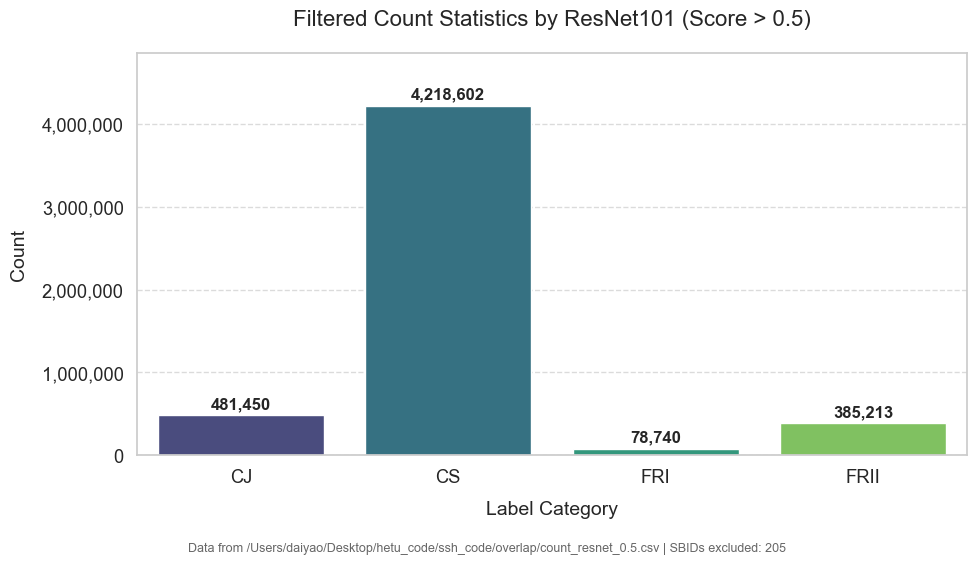

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set English font support
plt.rcParams["font.family"] = ["Arial", "DejaVu Sans", "Helvetica"]
sns.set(font_scale=1.2)
sns.set_style("whitegrid")

def process_csv_file():
    # Define SBIDs to exclude
    exclude_sbids = [
    20151, 20152, 20158, 20160, 20161, 20165, 20166, 20167, 20168, 20169,
    20171, 20172, 20174, 20175, 22648, 22649, 22654, 22659, 22660, 22661,
    22662, 22665, 22666, 22667, 22668, 22669, 22672, 22673, 22674, 22675,
    22678, 22679, 22818, 22819, 22820, 22821, 22839, 22882, 22883, 22885,
    22886, 22895, 22896, 22899, 22900, 22901, 25440, 25441, 25442, 25443,
    25444, 25445, 25446, 25451, 25452, 25453, 25458, 25459, 25460, 25461,
    25462, 25465, 25466, 25467, 25468, 25471, 25472, 25473, 25474, 25477,
    25478, 25479, 25480, 25485, 25486, 25487, 25488, 25491, 25493, 25494,
    25497, 25498, 25499, 25500, 25655, 25702, 25703, 25704, 25707, 25870,
    25871, 25872, 33088, 33117, 20164, 20170, 20173, 20176, 20210, 20211,
    20212, 20213, 20258, 20259, 20260, 20261, 20262, 20263, 20265, 20279,
    20280, 20281, 20285, 20286, 20287, 20289, 20301, 20368, 20370, 20371,
    20479, 20480, 20481, 20484, 20485, 20487, 20488, 20490, 20592, 20593,
    20610, 20611, 20639, 20640, 20641, 20642, 20646, 20647, 20648, 20649,
    20650, 20651, 20652, 33588, 33590, 33591, 20266, 20267, 20268, 20288,
    20290, 20291, 20292, 20293, 20294, 20295, 20296, 20298, 20299, 20300,
    20303, 20304, 20305, 20306, 20372, 20373, 20374, 20375, 20376, 20377,
    20482, 20483, 20486, 20505, 20534, 20535, 20536, 20540, 20594, 20595,
    20612, 20613, 20614, 20615, 20616, 20617, 20643, 20645, 20653, 20654,
    20655, 20656, 20657, 20676, 20677, 20678, 20715, 20716, 20717, 20718,
    20719, 33090,20712,20776,20659
]
    # Read CSV file
    file_path = input("Enter CSV file path: ")
    df = pd.read_csv(file_path)
    print(f"Successfully loaded file: {file_path}")
    print(f"Data shape: {df.shape}")
    
    # Check required columns
    required_columns = ['SBID', 'label_0_count_filtered', 'label_1_count_filtered', 
                        'label_2_count_filtered', 'label_3_count_filtered']
    missing_columns = [col for col in required_columns if col not in df.columns]
    if missing_columns:
        raise ValueError(f"Missing required columns: {missing_columns}")
    
    # Remove rows with excluded SBIDs
    original_count = len(df)
    df_filtered = df[~df['SBID'].isin(exclude_sbids)]
    removed_count = original_count - len(df_filtered)
    print(f"Removed {removed_count} rows containing excluded SBIDs")
    
    # Calculate totals for each label
    label_totals = {}
    for i in range(4):
        col_name = f'label_{i}_count_filtered'
        total = df_filtered[col_name].sum()
        label_totals[col_name] = total
        print(f"{col_name}: Total = {total:,}")
    
    # Calculate median
    #median_value = pd.Series(list(label_totals.values())).median()
    #print(f"Median: {median_value:,}")
    
    # Prepare data for plotting
    labels = ['CJ', 'CS', 'FRI', 'FRII']
    values = [label_totals[f'label_{i}_count_filtered'] for i in range(4)]
    
    # Create bar plot
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(x=labels, y=values, palette="viridis")
    
    # Add data labels (show exact values)
    max_value = max(values)
    for i, v in enumerate(values):
        ax.text(i, v + 0.02 * max_value, f'{v:,}', 
                ha='center', fontsize=12, fontweight='bold')
    
    # Set title and labels (optimized display)
    plt.title('Filtered Count Statistics by ResNet101 (Score > 0.5)', fontsize=16, pad=20)
    plt.xlabel('Label Category', fontsize=14, labelpad=10)
    plt.ylabel('Count', fontsize=14, labelpad=10)
    
    # Adjust Y-axis to better show the values
    plt.ylim(0, max_value * 1.15)  # Add 15% padding at top for labels
    
    # Set Y-axis format with thousands separators
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{int(x):,}'))
    
    # Add caption with data information
    plt.figtext(0.5, 0.01, 
                f"Data from {file_path} | SBIDs excluded: {len(exclude_sbids)} ", 
                ha="center", fontsize=9, alpha=0.7)
    
    # Add grid lines for better readability
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Display chart
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Make room for caption
    plt.show()

if __name__ == "__main__":
    try:
        process_csv_file()
    except Exception as e:
        print(f"Error encountered: {e}")

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
csv_file = "/Users/daiyao/Desktop/hetu_code/ssh_code/crossmatch/plot_count_final_0.5.csv"
df = pd.read_csv(csv_file)

df = df[df["CRVAL2"] <= 32.5]

print(df["label_0_count_maskb"].sum())
print(df["label_1_count_maskb"].sum())
print(df["label_2_count_maskb"].sum())
print(df["label_3_count_maskb"].sum())
#CJ sources:   496,420
#CS sources: 4,229,584
#FRI sources: 114,815
#FRII sources: 399,171

496420
4229584
114815
399171


In [3]:
# 1) RA 跨 0/360 的行（最可疑）
wrap_rows = data[data["ra_min_deg"] > data["ra_max_deg"]]
print("RA wrap rows:", len(wrap_rows))
if len(wrap_rows) > 0:
    print(wrap_rows[["ra_min_deg","ra_max_deg","dec_min_deg","dec_max_deg"]].head())

# 2) RA 范围特别宽的行（也可疑）
ra_span = (data["ra_max_deg"] - data["ra_min_deg"]).abs()
wide_rows = data[ra_span > 180]  # 阈值也可以改 120/150 看情况
print("Very wide RA rows:", len(wide_rows))
if len(wide_rows) > 0:
    print(wide_rows[["ra_min_deg","ra_max_deg","dec_min_deg","dec_max_deg"]].head())

# 3) 极区（投影压扁容易成条）
polar_rows = data[(data["dec_min_deg"] < -80) | (data["dec_max_deg"] > 80)]
print("Polar-ish rows:", len(polar_rows))

RA wrap rows: 0
Very wide RA rows: 2
      ra_min_deg  ra_max_deg  dec_min_deg  dec_max_deg
1093  258.521416  461.146666   -86.410915   -83.610574
1354   77.244127  282.714606   -86.305203   -83.533238
Polar-ish rows: 24


rows used: 1318


/var/folders/mz/pg3ztpgj1f10l242jx2qkjz80000gn/T/ipykernel_30374/4101535101.py:58: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  m_s = hp.smoothing(m0,fwhm=fwhm,verbose=False)
/var/folders/mz/pg3ztpgj1f10l242jx2qkjz80000gn/T/ipykernel_30374/4101535101.py:59: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  w_s = hp.smoothing(weight,fwhm=fwhm,verbose=False)


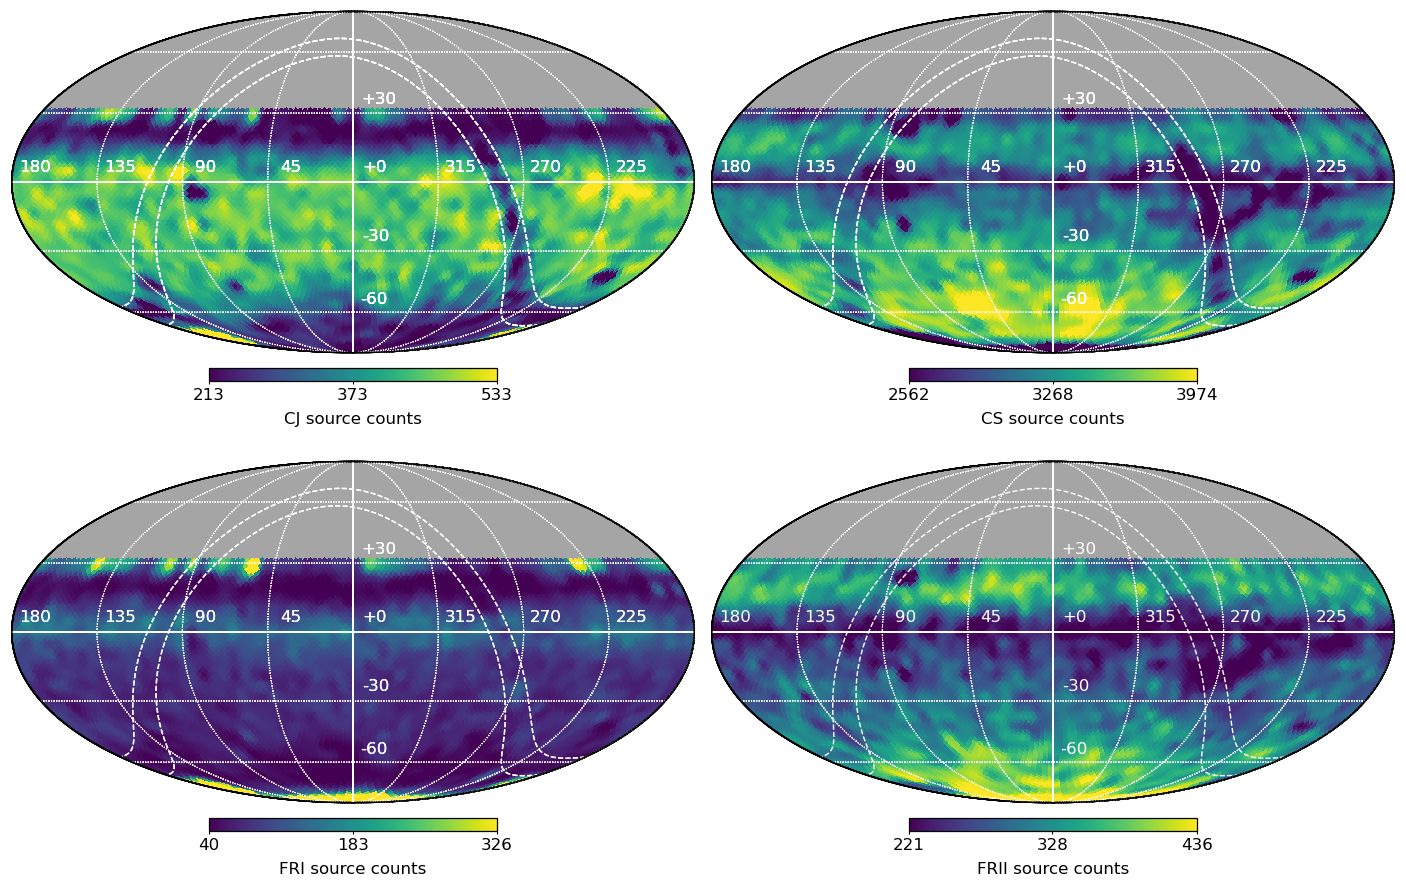

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import healpy as hp
from astropy.coordinates import SkyCoord
import astropy.units as u
import matplotlib as mpl

# ============================================================
# 参数
# ============================================================

csv_file = "/Users/daiyao/Desktop/hetu_code/ssh_code/crossmatch/plot_count_final_0.5.csv"
#csv_file = "/Users/daiyao/Desktop/hetu_code/ssh_code/crossmatch/plot_count_final_0.5_fixed.csv"

nside = 32
coord_sys = "C"

dec_max = 32.5
fwhm_deg = 5

BADGRAY = "0.65"

FIGSIZE = (14,9)

GRID_KW = dict(dpar=30, dmer=45, color="white", alpha=0.9, lw=0.7)

CBAR_HEIGHT = 0.014
CBAR_PAD = 0.015
CBAR_SHRINK = 0.42

PANELS = [
("label_0_count_maskb","CJ number","viridis"),
("label_1_count_maskb","CS number","viridis"),
("label_2_count_maskb","FRI number","viridis"),
("label_3_count_maskb","FRII number","viridis"),
]

LABELS = [
"CJ source counts",
"CS source counts",
"FRI source counts",
"FRII source counts"
]

# ============================================================
# 平滑填充
# ============================================================

def smooth_fill_below_dec(m,nside,dec_max_deg,fwhm_deg):

    weight = (m != hp.UNSEEN).astype(float)

    m0 = m.copy()
    m0[m0==hp.UNSEEN] = 0

    fwhm = np.deg2rad(fwhm_deg)

    m_s = hp.smoothing(m0,fwhm=fwhm,verbose=False)
    w_s = hp.smoothing(weight,fwhm=fwhm,verbose=False)

    m_fill = m_s/np.maximum(w_s,1e-6)

    ipix = np.arange(hp.nside2npix(nside))

    theta,phi = hp.pix2ang(nside,ipix)

    dec = 90-np.rad2deg(theta)

    m_fill[dec>dec_max_deg] = hp.UNSEEN

    return m_fill


# ============================================================
# 银河带
# ============================================================

def draw_galactic_band():

    l = np.linspace(0,360,2000)*u.deg

    for b in [+5,-5]:

        gal = SkyCoord(l=l,b=np.full(l.size,b)*u.deg,frame="galactic")

        icrs = gal.icrs

        hp.projplot(
            icrs.ra.deg,
            icrs.dec.deg,
            lonlat=True,
            coord=[coord_sys],
            color="white",
            linestyle="--",
            linewidth=1.0,
            alpha=1
        )


# ============================================================
# 读取数据
# ============================================================

df = pd.read_csv(csv_file)

df = df[df["CRVAL2"]<=dec_max].copy()

print("rows used:",len(df))


# ============================================================
# HEALPix投影
# ============================================================

ra = df["CRVAL1"].to_numpy(float)
dec = df["CRVAL2"].to_numpy(float)

theta = np.deg2rad(90-dec)
phi = np.deg2rad(ra)

pix = hp.ang2pix(nside,theta,phi)

npix = hp.nside2npix(nside)


# ============================================================
# 创建画布
# ============================================================

fig = plt.figure(figsize=FIGSIZE)


# ============================================================
# 2x2绘图
# ============================================================

for i,(col,title,cmap) in enumerate(PANELS,start=1):

    values = df[col].to_numpy(float)

    m = np.full(npix,hp.UNSEEN)

    sum_pix = np.zeros(npix)
    cnt_pix = np.zeros(npix)

    good = np.isfinite(values)

    np.add.at(sum_pix,pix[good],values[good])
    np.add.at(cnt_pix,pix[good],1)

    mask = cnt_pix>0

    m[mask] = sum_pix[mask]/cnt_pix[mask]

    m_plot = smooth_fill_below_dec(m,nside,dec_max,fwhm_deg)

    finite = m_plot[m_plot!=hp.UNSEEN]

    vmin = int(np.floor(np.nanpercentile(finite,5)))
    vmax = int(np.ceil(np.nanpercentile(finite,99)))

    hp.mollview(
        m_plot,
        coord=coord_sys,
        cmap=cmap,
        min=vmin,
        max=vmax,
        cbar=False,
        title="",
        unit="",
        notext=True,
        sub=(2,2,i),
        badcolor=BADGRAY
    )

    ax = plt.gca()
    plt.sca(ax)

    # 网格
    #hp.graticule(local=True, **GRID_KW)

    # 银河带
    draw_galactic_band()

    # RA刻度
    ra_ticks=[180,135,90,45,315,270,225]

    for r in ra_ticks:

        hp.projtext(
            r-12,
            4.5,
            f"{r}",
            lonlat=True,
            coord=[coord_sys],
            fontsize=12,
            ha="center",
            color="white"
        )

    # DEC刻度
    dec_ticks=[30,0,-30,-60]

    for d in dec_ticks:

        hp.projtext(
            -5,
            d+4.5,
            f"{d:+d}",
            lonlat=True,
            coord=[coord_sys],
            fontsize=12,
            ha="left",
            color="white"
        )

    # 外框
    ax.patch.set_linewidth(0.9)
    ax.patch.set_edgecolor("black")


    # ====================================================
    # colorbar
    # ====================================================

    pos = ax.get_position()

    width = pos.width*CBAR_SHRINK
    left = pos.x0+(pos.width-width)/2
    bottom = pos.y0-CBAR_PAD-CBAR_HEIGHT

    cax = fig.add_axes([left,bottom,width,CBAR_HEIGHT])

    norm = mpl.colors.Normalize(vmin=vmin,vmax=vmax)

    cb = fig.colorbar(
        mpl.cm.ScalarMappable(norm=norm,cmap=cmap),
        cax=cax,
        orientation="horizontal"
    )

    ticks = np.linspace(vmin,vmax,3)
    ticks = np.round(ticks).astype(int)

    cb.set_ticks(ticks)
    cb.ax.tick_params(labelsize=12,length=2,width=0.8)

    cb.outline.set_linewidth(0.9)

    # colorbar label

    cax.text(
        0.5,
        -2.5,
        LABELS[i-1],
        transform=cax.transAxes,
        ha="center",
        va="top",
        fontsize=12
    )

    plt.sca(ax)

    
for ax in fig.axes:
    plt.sca(ax)
    hp.graticule(**GRID_KW)

# ============================================================
# 布局
# ============================================================

fig.subplots_adjust(
left=0.03,
right=0.97,
top=0.95,
bottom=0.08,
wspace=0.10,
hspace=0.22
)

plt.savefig("/Users/daiyao/Desktop/hetu_code/ssh_code/crossmatch/healpix_4panel_scientific.pdf",dpi=400, bbox_inches="tight")
plt.show()